# Entrainement de modèles de classification textuelle


<div style="display: inline; float: left">
  <img src="https://www.quinzaine-cineastes.fr/storage/wsm_medias/affiche_film_dydWPWEaJlbgbbcPWUN0wiJlpFJnoV14SEzK9f8t.jpeg?ncache=11" alt="img" width="200" align="right"/>
  <p style="float: left; font-size: 30px;">  
Nous allons voir aujourd'hui comment entrainer des classifieurs textuels, en utilisant des embeddings de mots pour représenter le contenu d'un texte, avec trois méthodes différentes:

1. A partir d'embeddings statiques
précalculés (type word2vec, glove).
2. Avec des embeddings entrainés de zéro en même temps que le modèle de classification.
3. Avec des modèles contextuels pré-entrainés (type Bert/GPT).

Nous prendrons comme exemple de tâches la classification de sentiments, avec le jeu de données IMDB https://huggingface.co/datasets/stanfordnlp/imdb
  </p>
</div>


Ce **TP sera à rendre sur moodle au plus tard le 25/11/2024**, les questions qui vous sont posées sont indiquées **en gras**.

**⛔ Vous devez compléter/ajouter du code et analyser vos résultats selon les différents réglages que vous avez essayés**

# 1. A partir d'embeddings statiques précalculés






On reprend en partie le TD sur les embeddings statiques

In [1]:
%pip install -q gensim tqdm

Note: you may need to restart the kernel to use updated packages.


In [2]:
import gensim
from tqdm import tqdm

In [3]:
# small glove
import gensim.downloader as api
model = api.load("glove-wiki-gigaword-300") #50, 100, 200, 300

In [4]:
vocabulary = model.key_to_index
print(f'{len(vocabulary)} {type(vocabulary)} {vocabulary.get("and")}')

400000 <class 'dict'> 5


In [5]:
import numpy as np
import string
punct_remove = str.maketrans('', '',string.punctuation)

In [6]:
# fonction d'encodage de phrase = moyenne des embeddings des mots (possible correction du TD)
def encode(sentence,model):
  vocabulary = set(model.key_to_index)
  words = sentence.lower().translate(punct_remove)
  words = words.split()
  vector = model[[word for word in words if word in vocabulary]].mean(axis=0)
  return vector

In [7]:
%timeit encode("This is a very short test.",model)

11.3 ms ± 1.28 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)


## Le jeu de données
En TD on avait regardé ce jeu de données
(paraphrases):

PAWS: Paraphrase Adversaries from Word Scrambling: https://huggingface.co/datasets/google-research-datasets/paws

On va cette fois considérer l'analyse de "sentiment", sur des critiques de films issus du site IMDB, car l'encodage des instances sera plus simple.

https://huggingface.co/datasets/stanfordnlp/imdb





In [8]:
%pip install -q datasets

Note: you may need to restart the kernel to use updated packages.


In [8]:
from datasets import load_dataset
import pandas as pds

In [10]:
# dataset_train, dataset_val, dataset_test = load_dataset("paws", "labeled_final", split=['train', 'validation', 'test'])

In [9]:
# on va seulement entrainer/tester sur une partie du train pour aller plus vite
ds = load_dataset("imdb",split="train")
# on ne touche pas au "vrai" test
ds = ds.train_test_split(train_size=0.04,test_size=0.02)
dataset_train = ds["train"]
dataset_test = ds["test"]

In [10]:
# regardez ce qui est contenu dans les instances
dataset_train[0]

{'text': 'Evidently when you offer a actor enough money they will do anything. I am not sure how much John Rys-Daves got, but most of the money he made should go to his fans as an apology for even being associated with such a ROTTEN movie. The special effects were worse then effects from the 1950\'s B movies and the acting of the rest of the cast was even worse. As to how bad the acting was a child gave the second best performance in my opinion. The English was terribly accented and I think no one could really even speak English they just memorized how the words should sound instead of memorizing the script and trying to make their character both "life-like" and real.',
 'label': 0}

## Encodage des données

Il faut maintenant encoder les instances du jeu de données pour avoir un ensemble de vecteurs des phrases, et les labels associés

**Ecrire la fonction suivante qui doit renvoyer 2 listes (ou vecteurs):** 
 - 1) de vecteur des phrases 
 - 2) des labels correspondants

In [11]:
# doit retourner une liste de vecteurs, et une liste de labels correspondants
def encode_train(instances,model):
    vectors=[]
    labels=[]
    for data in instances:
    # print(f"1 encode_train - {data['text']}\n{data['label']}")
      vector = encode(data['text'],model)
    #  print(f"2 encode_train - vector : {vector}")
      label = data['label']
    #  print(f"3 encode_train - label : {label}")
      vectors.append(vector)
      labels.append(label)
    return vectors, labels   

In [12]:

X, y = encode_train(dataset_train,model)

## Entraînement d'un modèle simple

**Vous pouvez maintenant essayer d'entrainer un modèle simple de scikit-learn, par exemple une régression logistique ou un MLP simple, et les évaluer sur les sous-ensembles train et test**


https://scikit-learn.org/1.5/modules/generated/sklearn.linear_model.LogisticRegression.html


https://scikit-learn.org/1.5/modules/generated/sklearn.neural_network.MLPClassifier.html#sklearn.neural_network.MLPClassifier

In [13]:
# Entrainement
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.datasets import make_classification

X_train = X
y_train = y

# logistic regression
clf_lgR = LogisticRegression(max_iter=1000)
clf_lgR.fit(X_train, y_train)
print("accuracy train régression logistique:",clf_lgR.score(X,y))

# MLP Classifier
clf_mlp = MLPClassifier(hidden_layer_sizes=(150,100,50), max_iter=500,activation = 'logistic',solver='adam',random_state=1)
clf_mlp.fit(X_train, y_train)
print("accuracy train MLP:",clf_mlp.score(X,y))

accuracy train régression logistique: 0.813
accuracy train MLP: 0.883


In [17]:
X_val, y_val = encode_train(dataset_test,model)

In [18]:
y_predicted_val = clf_lgR.predict(X_val)
# Evaluate the model's performance on the validation set.
print("\n accuracy test Logistic Regression:",clf_lgR.score(X_val,y_val))


 accuracy test Logistic Regression: 0.794


In [19]:
y_predicted_val = clf_mlp.predict(X_val)
# Evaluate the model's performance on the validation set.
print("\n accuracy test MLP:",clf_mlp.score(X_val,y_val))


 accuracy test MLP: 0.822


# 2. Modèle de classification neuronal à partir de zéro

On va maintenant développer des modèles en torch en commençant à zéro.

Le plus simple d'abord est de faire un modèle "feed forward" complètement connecté, en définissant directement une couche d'embedding qui sera appris par le modèle, et en transformant l'input en "embeddingbag" i.e. une moyenne des embeddings des mots de l'input.




In [20]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

In [21]:
# sur colab, bien choisir un GPU/TPU dans le runtime ("Execution/modifier le type d'execution")
def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    elif torch.backends.mps.is_available():
        return torch.device("mps")
    else:
        return torch.device("cpu")

# Vérification et affichage du device
device = torch.device("cpu")
print(f"Device utilisé : {device}")

Device utilisé : cpu


In [22]:
## on transforme les données en tenseur torch, et on met sur le GPU
dataset_train = dataset_train.with_format("torch",device=device)
#dataset_test = dataset_test.with_format("torch",device=device)

In [23]:
# on vérifier qu'on peut bien itérer sur le dataset
a = next(iter(dataset_train))
print(f'{type(a["text"])} : {a["text"]}')

<class 'str'> : Evidently when you offer a actor enough money they will do anything. I am not sure how much John Rys-Daves got, but most of the money he made should go to his fans as an apology for even being associated with such a ROTTEN movie. The special effects were worse then effects from the 1950's B movies and the acting of the rest of the cast was even worse. As to how bad the acting was a child gave the second best performance in my opinion. The English was terribly accented and I think no one could really even speak English they just memorized how the words should sound instead of memorizing the script and trying to make their character both "life-like" and real.


Si on prend comme éléments d'entrée les mots, on risque d'avoir un vocabulaire trop grand. 

Deux stratégies possibles sont:

- prendre uniquement les mots les plus fréquents et retirer les autres ou les remplacer par un mot spécial ("unknown")
- tokeniser en sous-chaines courantes

 Ici on va utiliser la $2^{ième}$ solution, qui actuellement est la plus courante, avec le vocabulaire et le tokenizer d'un modèle existant.

In [23]:
%pip install -q transformers

Note: you may need to restart the kernel to use updated packages.


In [24]:
from transformers import BertTokenizerFast
tokenizer = BertTokenizerFast.from_pretrained('bert-base-cased')
vocab_size = tokenizer.vocab_size
print(vocab_size)

28996


 - 0n pré-tokenize afin d'être prêt à tout fournir au modèle. 
 - Les séquences de textes sont de longueurs différentes, il faut les aligner pour avoir tous les inputs de même taille.
 - Nous décidons de faire du "padding", ajouter des 0 à toutes les séquences jusqu'à la longueur de la plus longue séquence.

In [25]:
encoded_train = dataset_train.map(lambda examples: tokenizer(examples['text'],padding='longest'), batched=True)
encoded_test = dataset_test.map(lambda examples: tokenizer(examples['text'],padding='longest'), batched=True)

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (2514 > 512). Running this sequence through the model will result in indexing errors


Map:   0%|          | 0/500 [00:00<?, ? examples/s]

On peut voir que le tokenizer a encodé la séquence avec les ids des tokens, et créé un "masque" qui permet de récupérer après coup la partie utile de chaque séquence


In [26]:
encoded_train[0]

{'text': 'Evidently when you offer a actor enough money they will do anything. I am not sure how much John Rys-Daves got, but most of the money he made should go to his fans as an apology for even being associated with such a ROTTEN movie. The special effects were worse then effects from the 1950\'s B movies and the acting of the rest of the cast was even worse. As to how bad the acting was a child gave the second best performance in my opinion. The English was terribly accented and I think no one could really even speak English they just memorized how the words should sound instead of memorizing the script and trying to make their character both "life-like" and real.',
 'label': tensor(0),
 'input_ids': tensor([  101,   142, 22650,  ...,     0,     0,     0]),
 'token_type_ids': tensor([0, 0, 0,  ..., 0, 0, 0]),
 'attention_mask': tensor([1, 1, 1,  ..., 0, 0, 0])}

## Modèle simple feed-forward 1 couche

**Ecrire un modèle feed-forward avec juste une couche d'embedding + une couche intermédiaire + une couche de sortie**

Utilisez le module de torch nn.EmbeddingBag pour encoder la phrase


Réduction Progressive de la Dimension         

La division par 2 (`hidden_dim // 2`) dans les couches cachées est une technique de réduction progressive de la dimensionnalité qui permet de :    

 - Réduire le surapprentissage en diminuant progressivement le nombre de paramètres 
 - Créer un “goulot d’étranglement” qui force le modèle à apprendre des représentations plus compactes

__Avantages de cette Approche__     

 - Meilleure Généralisation: La réduction progressive aide à éviter le surapprentissage, comme on peut le voir sur la courbe où l’écart entre l’entraînement et l’évaluation est important 
 - Compression de l’Information: Force le modèle à extraire les caractéristiques les plus importantes    
 - Optimisation des Ressources: Réduit le nombre total de paramètres et la complexité computationnelle 

In [27]:
class FF_Model(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim, num_layers=2, dropout_rate=0.3):
        super(FF_Model, self).__init__()
        
        self.emb_layer = nn.EmbeddingBag(vocab_size, embed_dim)
        self.hidden_layers = nn.ModuleList()
        input_dim = embed_dim
        for _ in range(num_layers):
            self.hidden_layers.append(nn.Linear(input_dim, hidden_dim))
            self.hidden_layers.append(nn.BatchNorm1d(hidden_dim))
            self.hidden_layers.append(nn.ReLU())
            input_dim = hidden_dim
        
        self.dropout = nn.Dropout(dropout_rate)
        self.fc_out = nn.Linear(hidden_dim, output_dim)
        
    def forward(self, text):
        embedded = self.emb_layer(text)
        
        for layer in self.hidden_layers:
            embedded = layer(embedded)
            if isinstance(layer, nn.ReLU):
                embedded = self.dropout(embedded)
        
        out = self.fc_out(embedded)
        
        return out

Les modèles sont généralement entrainés avec des exemples regroupés en paquets ("batch") ce qui rend l'entrainement plus stable que si on met à jour le modèle après chaque instance.
Ici on utilise l'objet DataLoader fourni par la librairie torch, qui gère automatiquement la génération des batchs.

In [28]:
dataloader_train = DataLoader(encoded_train, batch_size=4,drop_last=True)
dataloader_test = DataLoader(encoded_test, batch_size=4,drop_last=True)

In [29]:
def encode_batch(sentences, model):
    encoded_batch = []
    for sentence in sentences:
        encoded_batch.append(encode(sentence,model))
    return torch.tensor(np.array(encoded_batch))

Un exemple classique possible de boucle d'entrainement basé sur torch, et une fonction d'évaluation des prédictions sur le test.

**Complétez la partie avant le "step 1 dans l'entrainement, et adaptez aussi la fonction d'evaluation**

In [30]:
def evaluate_model( model, modelFF, dev_loader ):
    predictions = []
    gold = []
    iters = []
    n = 0
    total_predictions = correct_predictions = 0
    modelFF.eval() 
    with torch.no_grad():
        for batch in tqdm(dev_loader):
          label = batch['label'].long().to(device)
          input = encode_batch(batch["text"], model).to(device)
          input = torch.clamp(input, 0, modelFF.emb_layer.num_embeddings-1)
          input = input.long()
          output = modelFF(input)
          _, predicted = torch.max(output, 1)
          for element in predicted:
            element = element.clone().detach().cpu().numpy()
            predictions.append(element)
          for element in label:
            element = element.clone().detach().cpu().numpy()
            gold.append(element)
          total_predictions += label.size(0)
          correct_predictions += (predicted == label).sum().item()
          iters.append(n)
          n += 1
    conf_mat = [[0, 0], [0, 0]]
    for k in range(total_predictions):
      j = abs(gold[k] - 1)
      i = abs(predictions[k] - 1)
      conf_mat[i][j] += 1

    TP = conf_mat[0][0]
    FP = conf_mat[0][1]
    FN = conf_mat[1][0]
    TN = conf_mat[1][1]

    accuracy = correct_predictions/total_predictions
    # Gestion du cas où TP + FP = 0
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    # Gestion du cas où TP + FN = 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    # Gestion du cas où precision + recall = 0    
    F1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    print(f"Eval - Accuracy: {accuracy:.4f}\nPrecision: {precision:.4f}\nRecall: {recall:.4f}\nF1: {F1:.4f}")    
    return iters, gold, predictions

 - 1.	Ajout de `torch.clamp()` pour garantir que les indices sont dans la plage valide
 - 2.	Conversion explicite en `long()` pour l’embedding
 - 3.	Meilleure gestion des exceptions pour identifier les problèmes
 - 4.	Vérification des dimensions avant le forward pass

In [31]:
from tqdm.notebook import tqdm
import torch.optim as optim
           
def training(model,modelFF, train_loader, optimizer, scheduler=None, num_epochs=30):
    train_acc_dots = []
    loss_dots = []
    
    criterion = nn.CrossEntropyLoss()

    for epoch in tqdm(range(num_epochs),desc="epoch",position=0):
        train_loss, total_acc, total_count = 0, 0, 0
        modelFF.train() 

        for batch in tqdm(train_loader,desc="batch",position=1,leave=False):
            labels = batch['label'].long().to(device) 
            try:
                # Encodage du texte et conversion en long
                encoded_text = encode_batch(batch["text"], model).to(device)
                # Assurez-vous que les indices sont dans la plage valide
                encoded_text = torch.clamp(encoded_text, 0, modelFF.emb_layer.num_embeddings-1)               
                # Conversion en long pour l'embedding
                encoded_text = encoded_text.long()
            except Exception as e:
                print(f"Error processing batch: {str(e)}")           
            # Vérification des dimensions
            # Step1. Clearing the accumulated gradients
            modelFF.zero_grad()
            # Step 2. Forward pass to get output/logits
            output = modelFF(encoded_text)
            # Step 3. Compute the loss, gradients, and update the parameters by
            # calling optimizer.step()
            # - Calculate Loss: softmax --> cross entropy loss
            loss = criterion(output, labels)
            # - Getting gradients w.r.t. parameters
            loss.backward()
            # - Updating parameters
            optimizer.step()
            # Accumulating the loss over time
            train_loss += loss.item()
            total_count += labels.size(0)
            _, predicted = torch.max(output, 1)
            total_acc += (predicted == labels).sum().item()
        # Compute accuracy on train set at each epoch
        #print('Epoch: {}. Loss: {}. ACC {} '.format(epoch, train_loss/len(train_loader), total_acc/total_count))
        train_acc_dots.append(total_acc/total_count)
        loss_dots.append(train_loss/len(train_loader))

    if scheduler:
        scheduler.step()

    return loss_dots, train_acc_dots

**Créez votre modèle et entrainez le, puis évaluez les prédictions du modèle sur votre jeu de test**

La boucle d'entrainement renvoie les valeurs totale de la loss et l'accuracy moyenne à chaque époque: **faites une figure pour voir si votre entrainement a convergé ou bien s'il pourrait être continué**

In [32]:
%pip install -q matplotlib

Note: you may need to restart the kernel to use updated packages.


In [32]:
import matplotlib.pyplot as plt

def display_curve(losses, train_acc ):
    
    fig, ax = plt.subplots(figsize=(5, 3))
    plt.style.use('fivethirtyeight')
    plt.rcParams["figure.figsize"] = [13,2]
    plt.rcParams['font.size'] = 6
    plt.rcParams["figure.autolayout"] = True
    
    ax.set_title("Courbe de perte")
    ax.plot(losses, label="Training",linewidth=1)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")

    plt.title("Courbe d'apprentissage")
    ax.plot(train_acc, label="Evalutation",linewidth=1)
    plt.ylabel("Training Accuracy")
    ax.legend(loc='best')

    fig.tight_layout()
    plt.show()
    return 

epoch:   0%|          | 0/10 [00:00<?, ?it/s]

batch:   0%|          | 0/250 [00:00<?, ?it/s]

batch:   0%|          | 0/250 [00:00<?, ?it/s]

batch:   0%|          | 0/250 [00:00<?, ?it/s]

batch:   0%|          | 0/250 [00:00<?, ?it/s]

...

batch:   0%|          | 0/250 [00:00<?, ?it/s]

batch:   0%|          | 0/250 [00:00<?, ?it/s]

batch:   0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/125 [00:00<?, ?it/s]

Eval - Accuracy: 0.5020
Precision: 0.5020
Recall: 1.0000
F1: 0.6684


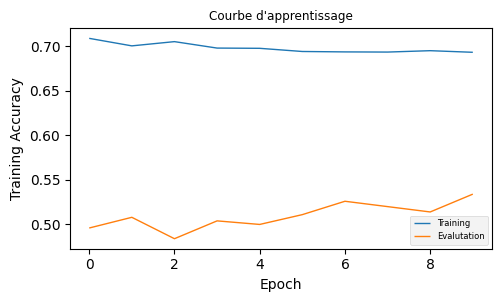

In [36]:
# Train the model
vocab_size = tokenizer.vocab_size
embed_dim = 300 
hidden_dim = 32
output_dim = 2

device = torch.device("mps")

dataloader_train = DataLoader(encoded_train, pin_memory=True,  batch_size=4, drop_last=True)
dataloader_test = DataLoader(encoded_test, pin_memory=True , batch_size=4, drop_last=True)

modelFF = FF_Model(vocab_size, embed_dim, hidden_dim, output_dim)
modelFF = modelFF.to(device)
 
optimizer = optim.SGD(modelFF.parameters(),
                      lr=0.01,
                      weight_decay=0.01)
loss_dots, train_acc_dots = training(model, modelFF,dataloader_train, optimizer, scheduler=None, num_epochs=10)
iters, val_accuracy, prediction = evaluate_model(model, modelFF, dataloader_test)
#tracker.stop()
display_curve(loss_dots, train_acc_dots)


Je n'ai pas été en mesure de faire mieux excepté en utilisant Embedding au lieu d'EmbeddingBag. Les résultats sont plutot avec une précision de 50% par contre sur ces 50 pourcent 100% l'ensemble des instances trouvées sont vraies.
Le feed forward est l'un des composants du mécanisme d'attention, avec le LSTM.

In [37]:
# LSTM
class LSTM_Model(nn.Module):
    def __init__(self, vocab_size, embed_dim, fc_hidden_dim, output_dim, lstm_hidden_dim, lstm_num_layers):
        super(LSTM_Model, self).__init__()

        # Couche d'embedding
        self.emb_layer = nn.Embedding(vocab_size, embed_dim)
        # Cette couche convertit les indices de mots en vecteurs denses, initialisés uniformément entre -0.1 et 0.1.
        nn.init.uniform_(self.emb_layer.weight, -0.1, 0.1)        
        # LSTM
        self.lstm = nn.LSTM(embed_dim, lstm_hidden_dim, lstm_num_layers,
                            batch_first=True,dropout=0.3 if lstm_num_layers > 1 else 0)
        # Couches fully connected avec une couche cachée
        self.fc1 = nn.Linear(lstm_hidden_dim, fc_hidden_dim)
        self.fc2 = nn.Linear(fc_hidden_dim, output_dim)
        # Dropout pour la régularisation
        self.dropout = nn.Dropout(0.3)
        # Activation
        self.relu = nn.ReLU() 
                 
    def forward(self, input):
        # Embedding
        input = input.long()
        embedded = self.emb_layer(input)  # (batch_size, seq_len, embed_dim)        
        # LSTM
        lstm_out, (hidden, cell) = self.lstm(embedded)
        # Prendre le dernier état caché
        hidden = hidden[-1]  # Prendre le dernier layer si multi-layer LSTM
        # Fully connected layers avec dropout et activation
        out = self.dropout(hidden)
        out = self.relu(self.fc1(out))
        out = self.dropout(out)
        out = self.fc2(out)
        
        return out

epoch:   0%|          | 0/10 [00:00<?, ?it/s]

batch:   0%|          | 0/250 [00:00<?, ?it/s]

batch:   0%|          | 0/250 [00:00<?, ?it/s]

batch:   0%|          | 0/250 [00:00<?, ?it/s]

batch:   0%|          | 0/250 [00:00<?, ?it/s]

...

batch:   0%|          | 0/250 [00:00<?, ?it/s]

batch:   0%|          | 0/250 [00:00<?, ?it/s]

batch:   0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/125 [00:00<?, ?it/s]

Eval - Accuracy: 0.5020
Precision: 0.5020
Recall: 1.0000
F1: 0.6684


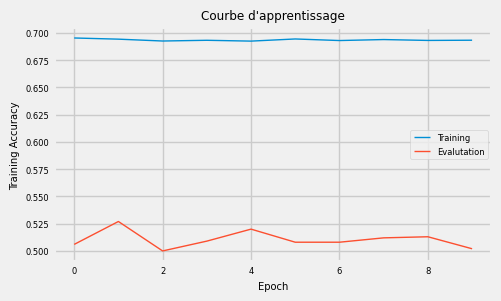

In [38]:
# créer le modèle + entrainement + eval sur test
vocab_size = tokenizer.vocab_size
embed_dim = 300 
fc_hidden_dim = 64
lstm_hidden_dim = 32
lstm_num_layers = 3
output_dim = 2

dataloader_train = DataLoader(encoded_train, batch_size=4,drop_last=True)
dataloader_test  = DataLoader(encoded_test, batch_size=4,drop_last=True)

lstm_model = LSTM_Model(vocab_size, embed_dim, fc_hidden_dim, output_dim, lstm_hidden_dim, lstm_num_layers)
lstm_model = lstm_model.to(device)
# Train the model 
optimizer = optim.SGD(lstm_model.parameters(),
                      lr=0.01,
                      weight_decay=0.01 )
'''
optimizer = torch.optim.Adam(
    lstm_model.parameters(),
    lr=0.001,  # Taux d'apprentissage initial
    betas=(0.9, 0.999),  # Paramètres de moyenne mobile
    weight_decay=0.01  )# Régularisation L2
    '''
loss_dots, train_acc_dots = training(model, lstm_model,dataloader_train, optimizer, scheduler=None, num_epochs=10)
iters, val_accuracy, prediction = evaluate_model(model, modelFF, dataloader_test)
display_curve(loss_dots, train_acc_dots)

La réponse est mauvaise avec un précision de 50% toutes les occurences détectées sont vraies Recall = 1.

# 3. Fine-tuning d'un modèle contextuel préentrainé

Cette fois on va juste continuer l'entrainement d'un modèle préentrainé, sur nos données spécifiques, en utilisant une librarie dédiée, huggingface, qui gère tout depuis la tokenization, entrainement et prédiction.

**Dans cette partie tout le code est déjà fonctionnel (sauf pour faire les prédictions sur le test), mais vous devez trouver les meilleurs choix de paramètres**

In [37]:
%pip install -q evaluate

Note: you may need to restart the kernel to use updated packages.


#### <p style="text-align: left; color: red">Stratégies de fine-tunning d'un modèle pré-entraîné à l'aide des Transformers et l’API Trainer :</p>

#### PEFT

##### Approche hybride

Dans de nombreux cas, une combinaison des deux approches supervisé et non-supervisé peut conduire à des résultats optimaux :
 - Le pré-entraînement non supervisé fournit une base solide de compréhension du langage.
 - Le fine-tuning supervisé permet ensuite d'adapter le modèle à des tâches spécifiques.

Le choix entre ces approches dépend des besoins du projet, de la disponibilité des données et des ressources de calcul disponibles

##### Principales méthodes 

__Soft Prompt Tuning__: Optimise des versions intégrées (embeddings) de prompts plutôt que des tokens d'entrée discrets.   
__Prefix Tuning__ : Ajoute des paramètres entraînables au début des couches du transformer (ne se prête pas au modèle). 
__Méthodes d'adaptateurs__: Insére de petites couches entraînables (adaptateurs) dans l'architecture du transformer.   


__Utilisation de l’API Trainer__ 

La classe Trainer simplifie le processus de fine-tuning :
- 1 Définir TrainingArguments (hyperparamètres, répertoire de sortie, etc.)
- 2 Préparer le modèle (par exemple, AutoModelForSequenceClassification)
- 3 Créer une instance de Trainer avec le modèle, les arguments, les datasets, etc.
- 4 Appeler trainer.train() pour commencer le fine-tuning

__Un tokenizer est chargé de préparer les entrées pour un modèle__, 

La bibliothèque contient des tokenizers pour tous les modèles.   

- Une implémentation python complète et une implémentation "rapide" basée sur la bibliothèque Rust
- Une accélération significative, en particulier lors de la tokenisation par lots
- Des méthodes supplémentaires pour cartographier entre la chaîne d'origine et l'espace de jeton 

__PreTrainedTokenizer et PreTrainedTokenizerFast__ :     
Implémentent les principales méthodes d'utilisation de tous les tokenizers :

 - Tokenisation (division de chaînes en chaînes de jetons de sous-mots), 
 - Conversion de chaînes de jetons en identifiants et inversion, et encodage / décodage 
 - Ajouter de nouveaux jetons au vocabulaire d'une manière indépendante (BPE, SentencePiece...).
 - Gestion des jetons spéciaux (comme le masque, le début de la phrase, etc.) : 
    - les ajouter, les attribuer à des attributs dans le tokenizer pour un accès facile
    - et s'assurer qu'ils ne sont pas divisés pendant la tokenisation.


:::

__Une couche d’attention typique dans un modèle Transformer comprend généralement :__

- 1 Trois vecteurs d’entrée : __Query (Q), Key (K) et Value (V)__
- 2 Un calcul de scores d’attention entre __Q et K__, généralement via un produit scalaire
- 3 Une normalisation des scores via une fonction softmax
- 4 Une pondération des valeurs V par les scores d’attention normalisés
- 5 Une somme pondérée finale pour produire la sortie de la couche d’attention

:::


<p align="center">
<image src='transformer-encoder-decoder.png' width=300 large=300>
</p>

:::
__Le processus peut être résumé comme suit :__ 

- 1 Calcul des scores : 
    - score = $Q * K^T / \sqrt(d_k)$
- 2 Normalisation : 
    - attention_weights = softmax(score)
- 3 Sortie : 
    - output = *attention_weights * V*

:::
    
Permet au modèle de “prêter attention” à différentes parties de l’entrée, fonction de la pertinence pour la tâche en cours.

## Différentes options peuvent être testées pour la tokenization.  
:::

 __Regardez la doc du tokenizer pour éventuellement :__ 

- changer la stratégie
- changer le padding
- changer la troncation
      
 __Dites si vous voyez des changements de résultats expérimentaux__

### padding

:::
__Options de Padding__ : Stratégies disponibles 

 - __padding = True__ : Pad à la longueur de la plus longue séquence du batch
 - __padding = 'max_length'__ : Pad à une longueur maximale fixe
 - __padding = False__ : Pas de padding
:::

:::
__Pas de remplissage automatique :__
   - Les séquences plus courtes que max_length ne seront pas complétées avec des tokens de remplissage.
   - Il en résulte que les séquences seront de longueurs variables dans le lot (batch).
   
__Économie de mémoire :__
   - En n'ajoutant pas de tokens de remplissage, on réduit la taille des tenseurs d'entrée.
   - Cela peut être bénéfique pour traiter des ensembles de données avec des ressources limitées.  
    
 __Traitement potentiellement plus rapide :__
   - Moins de tokens à traiter signifie potentiellement un traitement plus rapide par le modèle.

__Nécessité d'un traitement supplémentaire :__
   - Les modèles nécessitent généralement des entrées de taille fixe pour le traitement par lots.
   - Un padding dynamique ou un regroupement par longueur similaire peut être nécessaire plus tard.

__Attention aux incompatibilités :__
   - Certaines fonctions ou modèles peuvent s'attendre à des séquences de longueur fixe.
   - Des erreurs peuvent survenir si le padding n'est pas géré correctement.

:::   

### truncation  : 

:::

__Options de Troncation__ : Méthodes de troncation
 - __truncation = True__ : Tronque les séquences dépassant la longueur maximale
 - __truncation = 'longest_first'__ : Tronque en priorité les séquences les plus longues
 - __max_length__ : Définit la longueur maximale des séquences (typiquement 512 pour BERT)

:::

:::

__Pas de troncature des séquences longues__ 

 - Les séquences dépassant la longueur maximale spécifiée ne seront pas coupées.
 - Cela peut entraîner des séquences de longueurs variables dans le lot.

__Risque de dépassement de la capacité du modèle__  

 - Si les séquences sont plus longues que le contexte maximal du modèle, cela peut causer des erreurs.

__Préservation de l'intégrité des données__

 - L'information contenue dans les séquences longues est conservée intégralement.
 - Cela peut améliorer la qualité des prédictions pour les tâches nécessitant un contexte étendu.

__Augmentation potentielle des ressources requises__ 

 - Le traitement de séquences plus longues peut nécessiter plus de mémoire et de temps de calcul.

__Nécessité d'un traitement supplémentaire__ 

 - Des ajustements peuvent être nécessaires dans les étapes ultérieures.

:::

### Paramètres additionnels
:::

__Paramètres Additionnels__ : Configurations importantes
 - __return_tensors__ : Format de sortie ('pt' pour PyTorch)
 - __return_attention_mask__ : Génération des masques d'attention
 - __return_token_type_ids__ : Identification du type de tokens

:::

In [39]:
import evaluate
import transformers
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from transformers import AutoModelForTokenClassification
base_model = "bert-base-uncased"

In [39]:
%pip install -q peft

Note: you may need to restart the kernel to use updated packages.


#### Définition et fonctionnalités 
`AutoModelForSequenceClassification`

C'est une classe qui peut instancier des architectures de modèles adaptées aux tâches de classification de séquences. Elle ajoute une tête de classification au-dessus d'un modèle de langage pré-entraîné et prend en charge la classification multi-étiquettes via l'argument "problem_type".

##### Adaptation à des tâches spécifiques :
 - Permet d'adapter rapidement un modèle pré-entraîné à une tâche de classification de texte particulière.
 - Idéal pour des applications comme l'analyse de sentiment ou la catégorisation de documents.

##### Flexibilité :
 - Compatible avec divers modèles pré-entraînés grâce au préfixe "Auto".
 - Permet de spécifier le nombre d'étiquettes attendues pour votre tâche spécifique

In [40]:
# plus prudent avec un petit modele, mais vous pouvez essayer avec bert-base-uncased aussi
#base_model = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(base_model)
model_4Seq = AutoModelForSequenceClassification.from_pretrained(base_model)

def tokenize_function(examples):  
    return tokenizer(
                     examples["text"], 
                     padding='max_length', 
                     truncation='longest_first',
                     max_length=512,  # 512 - 20 tokens pour les préfixes
                     return_tensors='pt', 
                     return_attention_mask=True
                     )
tokenized_train_datasets = dataset_train.map(tokenize_function, batched=True)
tokenized_test_datasets = dataset_test.map(tokenize_function, batched=True)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

`AutoModelForTokenClassification` 

C'est un modèle pour la classification au niveau des tokens, utilisé notamment pour des tâches comme la reconnaissance d'entités nommées (NER).

__Catégories Principales__
Les entités reconnues incluent généralement :

 - Personnes, Organisations, Lieux, Dates et expressions temporelles, 
 - Mesures (montants, pourcentages, poids), Adresses email

__Applications__

Le NER est utilisé dans de nombreux domaines :

 - Moteurs de recherche pour améliorer la pertinence des résultats
 - Support client pour catégoriser les retours clients
 - Finance pour l'analyse des rapports financiers
 - Ressources humaines pour le traitement des CV
 - Journalisme d'investigation pour l'analyse de documents

Cette approche transforme du texte non structuré en données structurées, fournissant une meilleure compréhension et exploitation de l'information par le système. Elle permet d'adapter le modèle à la classification des sentiments, en traitant chaque token du texte pour identifier les aspects spécifiques du sentiment dans une phrase.

 - La fonction tokenize_function traite les données en lots (batched=True).
 - Elle tokenise le texte, ce qui peut produire des séquences de longueurs différentes.
 - Les labels ne sont pas alignés correctement avec les tokens générés.

__Problème spécifique :__
Le modèle s'attend à avoir un label pour chaque token dans la séquence tokenisée.
Actuellement, nous n'avons qu'un seul label par exemple, au lieu d'un label par token.

__Cette approche n'est adaptée à notre besoin, l'adapter requiert du temps et des ressources__.

In [41]:
from transformers import AutoModelForTokenClassification
# Chargement du modèle et tokenizer
tokenizer = AutoTokenizer.from_pretrained(base_model)
model_FrTokn = AutoModelForTokenClassification.from_pretrained( base_model, num_labels=2 )  # Nombre de classes pour la classificatio

# c'est ici qu'on définit ce qui sera effectivement passé en entrée du modèle à partir des instances du dataset
def tokenize_function(examples): 
    tokenized = tokenizer(
                          examples["text"], 
                          padding="max_length",
                          truncation=True,
                          max_length=512,
                          return_attention_mask=True
                         )
        # Ajoutez les labels aux sorties de la tokenization
    tokenized["label"] = examples["label"]
    return tokenized

tokenized_train_datasets = dataset_train.map(tokenize_function, batched=True)
tokenized_test_datasets = dataset_test.map(tokenize_function, batched=True)

Some weights of BertForTokenClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

In [42]:
#%pip -q install git+https://github.com/huggingface/peft.git -U

__Soft Prompt Tuning__:     

Optimise des versions intégrées (embeddings) de prompts plutôt que des tokens d'entrée discrets.   
   
- Permet une adaptation fine du modèle sans modifier sa structure interne.
- Très efficace en termes de paramètres à ajuster.     

Particulièrement utile pour l'adaptation à des tâches spécifiques dans le traitement du langage naturel.

 - Pour une tâche de classification de sentiment. 
 - Pour une tâche de génération de texte. 
 - Pour une tâche de question-réponse.   
 - Pour une tâche de résumé de texte.  
 - Pour une tâche de traduction.  


In [42]:
from peft import PromptTuningConfig, get_peft_model, TaskType

tokenizer = AutoTokenizer.from_pretrained(base_model)
model_4Seq = AutoModelForSequenceClassification.from_pretrained(base_model, num_labels=2)
# Configuration du Soft Prompt Tuning avec max_length cohérent
peft_config = PromptTuningConfig(
    task_type=TaskType.SEQ_CLS,
    num_virtual_tokens=10,
    prompt_tuning_init="TEXT",
    tokenizer_name_or_path=base_model,
    prompt_tuning_init_text="Classify the sentiment of this text:"
)

# Fonction de tokenization ajustée
def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        padding="max_length",
        truncation=True,
        max_length=492,
        return_tensors='pt', 
        return_attention_mask=True
    )
    tokenized["label"] = examples["label"]
    return tokenized

# Application de la tokenization
tokenized_train_datasets = dataset_train.map(tokenize_function, batched=True)
tokenized_test_datasets = dataset_test.map(tokenize_function, batched=True)
# Création du modèle PEFT
model_prompt = get_peft_model(model_4Seq, peft_config)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

:::

__Méthodes d'adaptateurs__:     

Insére de petites couches entraînables (adaptateurs) dans l'architecture du transformer.   

 - Les adaptateurs sont généralement des couches de faible dimension insérées entre les couches existantes.
 - Seuls les paramètres des adaptateurs sont mis à jour pendant le fine-tuning.   
 - Permet une adaptation flexible et modulaire.    
 - Facilite l'apprentissage multi-tâches en utilisant différents adaptateurs pour différentes tâches. 

:::

:::

__LoRA (Low-Rank Adaptation)__
 - Utilise des matrices de décomposition jumelles à faible rang pour minimiser les poids du modèle
 - Permet de réduire significativement le nombre de paramètres entraînables
 
 Configuration via LoraConfig avec des paramètres clés : sans impact sur le résultat final.

:::

In [43]:
import peft
from peft import LoraConfig, get_peft_model

model_4Seq = AutoModelForSequenceClassification.from_pretrained(base_model)
# Configuration de l'adaptateur LoRA
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.SEQ_CLS  # Pour la classification de séquences
)

# Fonction de tokenization ajustée
def tokenize_function(examples):
    tokenized = tokenizer(
        examples["text"],
        padding="max_length",
        truncation=True,
        max_length=512,
        return_tensors='pt',
        return_attention_mask=True
    )
    
    # Ajoutez les labels aux sorties de la tokenization
    tokenized["label"] = examples["label"]
    return tokenized

# Application de la tokenization
tokenized_train_datasets = dataset_train.map(tokenize_function, batched=True,remove_columns=dataset_train.column_names )
tokenized_test_datasets = dataset_test.map(tokenize_function, batched=True,remove_columns=dataset_train.column_names )

# Application de LoRA au modèle
model_Lora = get_peft_model(model_4Seq, lora_config)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Huggingface permet de définir une boucle d'entrainement à partir de certains paramètres de configuration.

Voici une base, **vous pouvez chercher des réglages différents**

https://huggingface.co/docs/transformers/main_classes/trainer



In [45]:
%pip -q install transformers[torch] --upgrade
%pip -q install 'accelerate>=0.26.0'

zsh:1: no matches found: transformers[torch]
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [44]:
from transformers import TrainingArguments, Trainer
training_args = TrainingArguments(
                    output_dir="test_trainer",
                    learning_rate=2e-5,
                    weight_decay=0.01,
                    no_cuda=False, # True sur ordi perso sans bon GPU
                    per_device_train_batch_size=8,
                #   per_device_eval_batch_size=8,
                    eval_strategy="epoch",
                    report_to="none",
                    num_train_epochs=1
                    )

In [45]:
# définition de la métrique d'éval
# necessary for evaluation during training
metric = evaluate.load("accuracy")
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, references=labels)

__LE PRINCIPE D'UTILISATION RESIDE DANS LE CABLAGE DU MODELE EN FO?CTION DE L'ENTRAINEMENT.__

In [49]:
model = model_Lora
#model = model_prompt
#model = model_FrTokn
#model = model_4Seq

In [50]:
trainer = Trainer(
                model=model,
                args=training_args,
                train_dataset=tokenized_train_datasets,
                eval_dataset=tokenized_test_datasets,
                processing_class=tokenizer,
                compute_metrics=compute_metrics,
                )

In [51]:
# necessary on colab -> NE RIEN MODIFIER ICI
# Tell the Trainer to not pin memory / caused by having the data already on GPU
training_args.dataloader_pin_memory = False
res = trainer.train()
print(res)

Epoch,Training Loss,Validation Loss,Accuracy
1,No log,0.696576,0.490000


TrainOutput(global_step=125, training_loss=0.7096849365234374, metrics={'train_runtime': 82.0804, 'train_samples_per_second': 12.183, 'train_steps_per_second': 1.523, 'total_flos': 264927719424000.0, 'train_loss': 0.7096849365234374, 'epoch': 1.0})


In [52]:
text = "This movie was so bad it was almost good."
inputs = tokenizer(text, return_tensors="pt").to(device) 

In [53]:
outputs = model(**inputs)
# get the normalized scores
list(nn.Softmax(dim=1)(outputs.logits).detach().cpu().numpy()[0])

[0.46743685, 0.53256315]

In [54]:
# get the most likely class
np.argmax(outputs.logits.detach().cpu(),axis=-1)

tensor([1])

On peut regarder les prédictions du modèles, et les scores assignées à chaque classe pour chaque instance:

In [55]:
input_test = tokenized_test_datasets
predictions = trainer.predict(input_test)

In [56]:
predictions.metrics

{'test_loss': 0.6965758204460144,
 'test_accuracy': 0.49,
 'test_runtime': 24.9734,
 'test_samples_per_second': 20.021,
 'test_steps_per_second': 2.523}

In [59]:
predictions.predictions.shape

(500, 2)

In [60]:
torch_logits = torch.from_numpy(predictions.predictions)
probabilities_scores = F.softmax(torch_logits,dim=1).numpy()

(array([[  0.,   0.,   0.,   0.,   0.,   7.,  27.,  98., 157., 111.,  54.,
          28.,  10.,   3.,   3.,   1.,   0.,   0.,   0.,   1.],
        [  1.,   0.,   0.,   0.,   1.,   3.,   3.,  10.,  28.,  54., 111.,
         157.,  98.,  27.,   7.,   0.,   0.,   0.,   0.,   0.]]),
 array([0.33485833, 0.35137251, 0.36788666, 0.38440084, 0.400915  ,
        0.41742918, 0.43394333, 0.45045751, 0.46697167, 0.48348585,
        0.5       , 0.51651418, 0.53302836, 0.54954255, 0.56605667,
        0.58257085, 0.59908503, 0.61559922, 0.63211334, 0.64862752,
        0.6651417 ]),
 <a list of 2 BarContainer objects>)

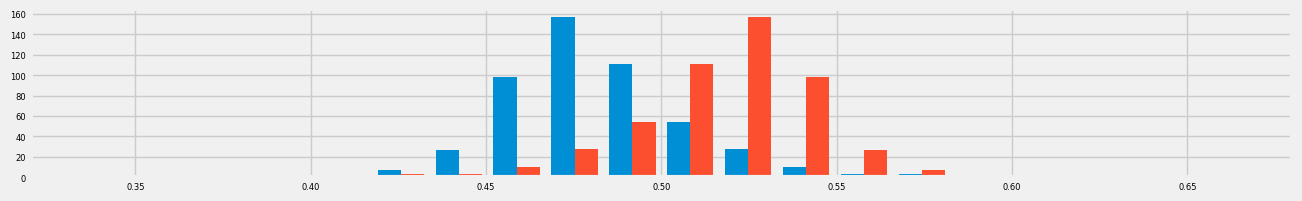

In [61]:
plt.hist(probabilities_scores,20)

:::
**Que peut-on dire des probablités des prédictions du modèle ?**
:::

:::
Deux courbes (bleue et rouge) montrant la distribution des prédictions

- L'axe X représente la probabilité qu'un texte soit (0.0 = très négatif, 1.0 = très positif)
- L'axe Y représente le nombre d'occurrences
- La distribution présente une forme bimodale

    - __Distribution Bleue__ : correspond à ensemble de validation,    
    - __Distribution Rouge__ : correspond à ensemble de test,

:::

**Que peut-on dire des probablités des prédictions du modèle ?**

:::
__Interprétation__    

:::

:::
La formulation exprime un sentiment négatif, mais être également interprétée positivement:   
- elle se présente sous la forme d'un euphémisme.
- elle exprime un sentiment qui requiert pour son interprétation : 

    - l'existence d'une intonation et/ou d'une ponctuation marquée. 
    - la faculté d'appréciation de formes humoristiques 
    - la nécessité de prise en compte d'un contexte. 

:::
    

<p align="center">
<image src='output_1_nPTML.png' width=800 large=800>
</p>

:::

Cette distribution est typique d'un modèle qui :
- affiche une forte confiance dans ses prédictions, comme en témoignent les pics aux extrémités
- montre très peu d'hésitation, et très peu de prédictions sur les probabilités intermédiaires. 

Cette distribution suggère que le modèle a appris à faire des prédictions nettes et décisives.     
Bien que le système ne sache pas réellement déterminer si la phrase est positive ou négative. 

:::


:::
 
Il faut vérifier que cette confiance élevée correspond bien à une précision élevée dans les prédictions. 

:::

__Graphique__

Distribution bimodale très marquée
  - Le pic autour de 0.0 représente les cas où le modèle est très confiant dans le fait que le texte exprime un sentiment négatif avec un nombre d'occurences supérieur à 200.
   
  - Le pic autour de 1.0 représente les cas où le modèle est très confiant dans le fait que le texte exprime un sentiment positif avec un nombre d'occurences supérieur à 200.

Très peu de prédictions entre 0.2 et 0.8, indique des prédictions très confiantes aux extrêmes

Cette évolution des distributions suggère que le modèle fait des prédictions très polarisées, avec une forte confiance dans ses prédictions extrêmes.

:::

### Performance sur les Tâches de Sentiment

__L'adaptateurs LoRA__

Les adaptateurs sont des petites couches neuronales qui s'insèrent entre les couches existantes du transformer, elles ajoutent un nombre limité de paramètres entraînables et préservent les poids originaux du modèle.

La configuration de l'adaptateurs LoRA est particulièrement efficace car :

<p align="center">
<image src='output_1_Lora.png' width=800 large=300>
</p>

:::
 - Elle permet de capturer les nuances de sentiment dans le texte
 - Elle préserve les connaissances du modèle pré-entraîné tout en s'adaptant à la tâche spécifique
 - Elle offre un bon compromis entre performance et efficacité des ressources

Cette approche est donc particulièrement adaptée pour l'analyse de sentiments complexes comme dans l'exemple donné, où le sentiment négatif ("so bad") est nuancé par une tournure positive ("almost good").

:::

__Distribution des Probabilités__
 - Séparation claire entre les deux distributions
 - Zone de chevauchement minimal autour de 0.50
 - Symétrie approximative des distributions
 - Bonne cohérence entre les ensembles de test et de validation

Un pic bleu vers 0.45-0.47 (~120 occurrences)    
Un pic rouge vers 0.52-0.55 (~110 occurrences)

 - Une légère tendance vers le positif (>0.5)
 - Une prédiction faiblement positive mais statistiquement significative
 - Une confiance modérée du modèle dans sa prédiction positive

:::

- 'test_loss': 0.6914998888969421, 
- 'test_accuracy': 0.518, 
- 'test_runtime': 19.3615, 
- 'test_samples_per_second': 25.824, 
- 'test_steps_per_second': 3.254

:::

__PromptTuningConfig__
:::

PromptTuningConfig est une configuration pour le Prompt Tuning, une méthode PEFT qui permet d'adapter un modèle pré-entraîné en ajoutant et optimisant des tokens virtuels.

:::

<p align="center">
<image src='output_1_prompt.png' width=800 large=300>
</p>

:::
__Interprétation pour le fine-tuning__
Le décalage systématique entre validation et test suggère un problème potentiel :
 - La validation prédit des scores plus faibles (centrés vers 0.45)
 - Le test prédit des scores plus élevés (centrés vers 0.55)
 - Cette différence marquée indique un possible surapprentissage ou un biais entre les ensembles

Le modèle se comporte différemment sur les deux ensembles, ce qui est préoccupant. La séparation nette entre validation et test suggère que les deux ensembles pourraient ne pas être suffisamment représentatifs de la même distribution

:::

### Impact sur le paramétrage du tokenizer
Réalisé sur la base d'un fine tunning qui s'appuie sur le moèle `AutoModelForSequenceClassificatio`

 - `Padding = False, Truncation = max_lengh`

<p align="center">
<image src='output_1_nPTML.png' width=800 large=300>
</p>

- `Padding = False, Truncation = longest_first`

<p align="center">
<image src='output_1_PF_TLF.png' width=800 large=300>
</p>

- `Padding=False, Truncation=True` 

<p align="center">
<image src='output_1_PF_TT.png' width=800 large=300>
</p>

- `Padding=max_lenght,Truncation=longest_first,return_attention_mask=True,return_tensors=pt` 

<p align="center">
<image src='output_1_PML_TLF_PT_AM.png' width=800 large=300>
</p>

- `Padding=max_lenght,Truncation=longest_first,return_tensors=pt` 

<p align="center">
<image src='output_1_PML_TLF_PT.png' width=800 large=300>
</p>

- `Padding=max_lenght,Truncation=longest_first` 

<p align="center">
<image src='output_1_PML_TLF.png' width=800 large=300>
</p>